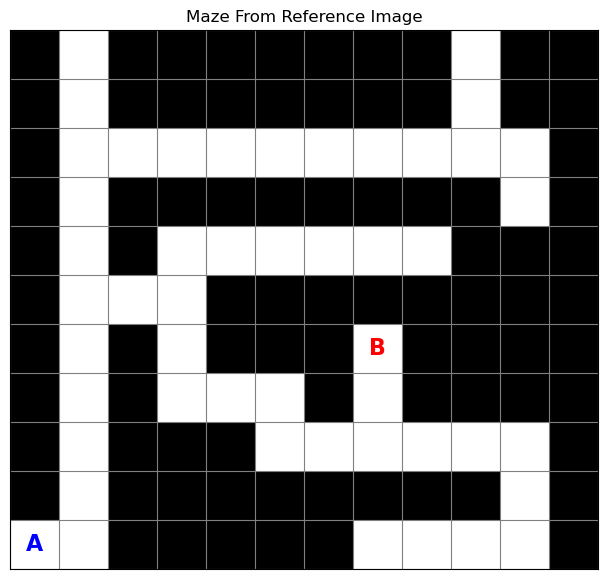

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 0 = path (white), 1 = wall (black)
maze = np.array([
    [1,0,1,1,1,1,1,1,1,0,1,1],
    [1,0,1,1,1,1,1,1,1,0,1,1],
    [1,0,0,0,0,0,0,0,0,0,0,1],
    [1,0,1,1,1,1,1,1,1,1,0,1],
    [1,0,1,0,0,0,0,0,0,1,1,1],
    [1,0,0,0,1,1,1,1,1,1,1,1],
    [1,0,1,0,1,1,1,0,1,1,1,1],
    [1,0,1,0,0,0,1,0,1,1,1,1],
    [1,0,1,1,1,0,0,0,0,0,0,1],
    [1,0,1,1,1,1,1,1,1,1,0,1],
    [0,0,1,1,1,1,1,0,0,0,0,1]
], dtype=int)

# Start (A) and Goal (B)
start = (10, 0)
goal = (6, 7)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(maze, cmap="gray_r", interpolation="nearest")

# Draw borders around every cell
rows, cols = maze.shape
ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# Labels
ax.text(start[1], start[0], "A", ha="center", va="center", color="blue", fontsize=16, fontweight="bold")
ax.text(goal[1], goal[0], "B", ha="center", va="center", color="red", fontsize=16, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Maze From Reference Image")
plt.show()

# 1. Find all the available nodes
# 2. Save a list of all the "0" node in this maze

In [16]:

available_nodes = []
#rows, cols = maze.shape

for i in range(rows):
    for j in range(cols):
        if maze[i, j] == 0:  
            available_nodes.append((i, j))

print (available_nodes)




[(0, 1), (0, 9), (1, 1), (1, 9), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (3, 1), (3, 10), (4, 1), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 1), (5, 2), (5, 3), (6, 1), (6, 3), (6, 7), (7, 1), (7, 3), (7, 4), (7, 5), (7, 7), (8, 1), (8, 5), (8, 6), (8, 7), (8, 8), (8, 9), (8, 10), (9, 1), (9, 10), (10, 0), (10, 1), (10, 7), (10, 8), (10, 9), (10, 10)]


In [20]:
possible_direction = ((0,1), (0,-1), (1,0), (-1,0))
#for each nodes makes a graph that can traverse through possible direction
#add edges/neighbors only if node is white "0"

'''Logic:

For each possible direction
next_row = row + d_row
next_col = col + d_col

0 <= next_row < rows and 0 <= next_col < cols and maze[next_row, next_col] == 0:'''

graph = {}
edges = []

for row, col in available_nodes:
    current = (row, col)
    neighbors = []
    for d_row, d_col in possible_direction:
        next_row = row + d_row
        next_col = col + d_col
        if 0 <= next_row < rows and 0 <= next_col < cols and maze[next_row, next_col] == 0:
            neighbor = (next_row, next_col)
            neighbors.append(neighbor)
            if current < neighbor:
                edges.append((current, neighbor))
        graph[current] = neighbors

graph


{(0, 1): [(1, 1)],
 (0, 9): [(1, 9)],
 (1, 1): [(2, 1), (0, 1)],
 (1, 9): [(2, 9), (0, 9)],
 (2, 1): [(2, 2), (3, 1), (1, 1)],
 (2, 2): [(2, 3), (2, 1)],
 (2, 3): [(2, 4), (2, 2)],
 (2, 4): [(2, 5), (2, 3)],
 (2, 5): [(2, 6), (2, 4)],
 (2, 6): [(2, 7), (2, 5)],
 (2, 7): [(2, 8), (2, 6)],
 (2, 8): [(2, 9), (2, 7)],
 (2, 9): [(2, 10), (2, 8), (1, 9)],
 (2, 10): [(2, 9), (3, 10)],
 (3, 1): [(4, 1), (2, 1)],
 (3, 10): [(2, 10)],
 (4, 1): [(5, 1), (3, 1)],
 (4, 3): [(4, 4), (5, 3)],
 (4, 4): [(4, 5), (4, 3)],
 (4, 5): [(4, 6), (4, 4)],
 (4, 6): [(4, 7), (4, 5)],
 (4, 7): [(4, 8), (4, 6)],
 (4, 8): [(4, 7)],
 (5, 1): [(5, 2), (6, 1), (4, 1)],
 (5, 2): [(5, 3), (5, 1)],
 (5, 3): [(5, 2), (6, 3), (4, 3)],
 (6, 1): [(7, 1), (5, 1)],
 (6, 3): [(7, 3), (5, 3)],
 (6, 7): [(7, 7)],
 (7, 1): [(8, 1), (6, 1)],
 (7, 3): [(7, 4), (6, 3)],
 (7, 4): [(7, 5), (7, 3)],
 (7, 5): [(7, 4), (8, 5)],
 (7, 7): [(8, 7), (6, 7)],
 (8, 1): [(9, 1), (7, 1)],
 (8, 5): [(8, 6), (7, 5)],
 (8, 6): [(8, 7), (8, 5)],
 (8,

In [21]:
from collections import deque

def bfs_path(graph, start_node, goal_node):
    queue = deque([start_node])
    parents = {start_node: None}
    while queue:
        current = queue.popleft()
        if current == goal_node:
            break
        for neighbor in graph[current]:
            if neighbor not in parents:
                parents[neighbor] = current
                queue.append(neighbor)
    if goal_node not in parents:
        return None

    path = []
    current = goal_node
    while current is not None:
        path.append(current)
        current = parents[current]

    path.reverse()
    return path
bfs_path(graph, start, goal)

[(10, 0),
 (10, 1),
 (9, 1),
 (8, 1),
 (7, 1),
 (6, 1),
 (5, 1),
 (5, 2),
 (5, 3),
 (6, 3),
 (7, 3),
 (7, 4),
 (7, 5),
 (8, 5),
 (8, 6),
 (8, 7),
 (7, 7),
 (6, 7)]